# Hotel Reservation Status Prediction — LightGBM Pipeline
> **Objective:** Predict hotel reservation status (Check-Out = 1, Canceled = 2, No-Show = 3)  
> **Model:** LightGBM (multiclass) with SMOTE oversampling, Optuna hyperparameter tuning, and full evaluation suite.

## 1. Setup & Imports

In [1]:
# Install dependencies if not already available
import subprocess, sys
for pkg in ['lightgbm', 'imbalanced-learn', 'optuna', 'shap']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully ✅')
print(f'LightGBM version: {lgb.__version__}')

All libraries loaded successfully ✅
LightGBM version: 4.6.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Data

In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/DSPL/train_encoded (1).csv')
valid_df = pd.read_csv('/content/drive/MyDrive/DSPL/valid_encoded (1).csv')
test_df  = pd.read_csv('/content/drive/MyDrive/DSPL/test_encoded.csv')

TARGET   = 'Reservation_Status'
DROP_COLS = ['Reservation_id', TARGET]

# Features
FEATURES = [c for c in train_df.columns if c not in DROP_COLS]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES], valid_df[TARGET]
X_test           = test_df[FEATURES]

# LightGBM uses 0-indexed classes
y_train_lgb = y_train - 1
y_valid_lgb = y_valid - 1

CLASS_NAMES = ['Check-Out (1)', 'Canceled (2)', 'No-Show (3)']

print(f'Train  : {X_train.shape}   |  Target dist: {dict(y_train.value_counts().sort_index())}')
print(f'Valid  : {X_valid.shape}   |  Target dist: {dict(y_valid.value_counts().sort_index())}')
print(f'Test   : {X_test.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Train  : (27491, 36)   |  Target dist: {1: np.int64(21235), 2: np.int64(4134), 3: np.int64(2122)}
Valid  : (2749, 36)   |  Target dist: {1: np.int64(1610), 2: np.int64(741), 3: np.int64(398)}
Test   : (4318, 36)
Features (36): ['Age', 'Adults', 'Children', 'Babies', 'Visted_Previously', 'Previous_Cancellations', 'Required_Car_Parking', 'Use_Promotion', 'Discount_Rate', 'Room_Rate', 'stay_nights', 'Lead_Days', 'Revenue', 'Expected_checkin_year', 'Expected_checkin_month', 'Gender_M', 'Ethnicity_Asian American', 'Ethnicity_Latino', 'Ethnicity_caucasian', 'Educational_Level_Grad', 'Educational_Level_High-School', 'Educational_Level_Mid-School', 'Income_50K -- 100K', 'Income_<25K', 'Income_>100K', 'Country_region_North', 'Country_region_South', 'Country_region_West', 'Hotel_Type_City Hotel', 'Hotel_Type_Resort', 'Meal_Type_FB', 'Meal_Type_HB', 'Deposit_type_Non-Refundable', 'Deposit_type_Refundable', 'Booking_channel_Direct', 'Booking_channel_Online']


## 3. Class Imbalance Visualisation

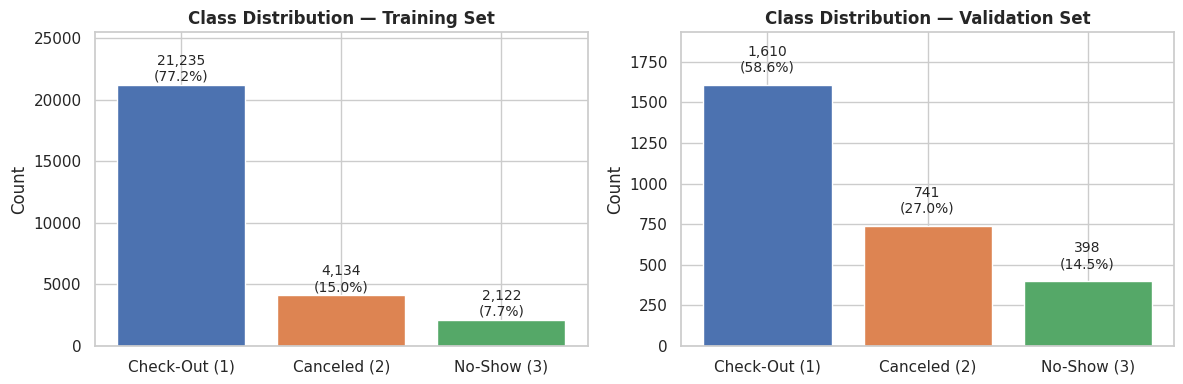

⚠️  Severe imbalance detected — Class 1 dominates at ~77% of train data


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, ser) in zip(axes, [('Training Set', y_train), ('Validation Set', y_valid)]):
    counts = ser.value_counts().sort_index()
    bars = ax.bar(CLASS_NAMES, counts.values, color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                f'{val:,}\n({val/len(ser)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Class Distribution — {label}', fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  Severe imbalance detected — Class 1 dominates at ~77% of train data')

## 4. Handling Class Imbalance — SMOTE Oversampling

In [5]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train_lgb)

print('Before SMOTE:', dict(pd.Series(y_train_lgb).value_counts().sort_index()))
print('After  SMOTE:', dict(pd.Series(y_train_bal).value_counts().sort_index()))
print(f'Training samples: {len(y_train_lgb):,} → {len(y_train_bal):,}')

Before SMOTE: {0: np.int64(21235), 1: np.int64(4134), 2: np.int64(2122)}
After  SMOTE: {0: np.int64(21235), 1: np.int64(21235), 2: np.int64(21235)}
Training samples: 27,491 → 63,705


## 5. Baseline LightGBM Model

In [6]:
baseline_params = {
    'objective'       : 'multiclass',
    'num_class'       : 3,
    'metric'          : 'multi_logloss',
    'n_estimators'    : 300,
    'learning_rate'   : 0.05,
    'num_leaves'      : 31,
    'max_depth'       : -1,
    'min_child_samples': 20,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.0,
    'reg_lambda'      : 1.0,
    'n_jobs'          : -1,
    'random_state'    : RANDOM_STATE,
    'verbose'         : -1
}

baseline_model = lgb.LGBMClassifier(**baseline_params)
baseline_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_valid, y_valid_lgb)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)]
)

y_pred_baseline_val  = baseline_model.predict(X_valid)
y_pred_baseline_train = baseline_model.predict(X_train)

baseline_val_acc = accuracy_score(y_valid_lgb, y_pred_baseline_val)
baseline_val_f1  = f1_score(y_valid_lgb, y_pred_baseline_val, average='weighted')

print(f'Baseline — Validation Accuracy : {baseline_val_acc:.4f}')
print(f'Baseline — Validation F1 (wtd) : {baseline_val_f1:.4f}')
print(f'Best iteration: {baseline_model.best_iteration_}')

Baseline — Validation Accuracy : 0.5584
Baseline — Validation F1 (wtd) : 0.4309
Best iteration: 27


## 6. Hyperparameter Tuning with Optuna (Fast)

In [28]:
def objective(trial):
    params = {
        'objective'        : 'multiclass',
        'num_class'        : 3,
        'metric'           : 'multi_logloss',
        'n_estimators'     : 500,
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_jobs'           : -1,
        'random_state'     : RANDOM_STATE,
        'verbose'          : -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_bal, y_train_bal,
        eval_set=[(X_valid, y_valid_lgb)],
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(False)]
    )
    preds = model.predict(X_valid)
    # Changed objective to optimize for macro F1-score
    return f1_score(y_valid_lgb, preds, average='macro')

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
# Increased n_trials for a more thorough search
study.optimize(objective, n_trials=60, show_progress_bar=False)

print(f'Best Macro F1    : {study.best_value:.4f}')
print(f'Best Params      :\n{study.best_params}')

Best Macro F1    : 0.2981
Best Params      :
{'learning_rate': 0.18872906373795967, 'num_leaves': 77, 'max_depth': 7, 'min_child_samples': 52, 'subsample': 0.6015737644458422, 'colsample_bytree': 0.9357239586720052, 'reg_alpha': 1.1842939778980232e-08, 'reg_lambda': 3.8976036435348793}


## 7. Train Final Tuned Model

In [29]:
best_params = study.best_params.copy()
best_params.update({
    'objective'   : 'multiclass',
    'num_class'   : 3,
    'metric'      : 'multi_logloss',
    'n_estimators': 1000,
    'n_jobs'      : -1,
    'random_state': RANDOM_STATE,
    'verbose'     : -1
})

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_valid, y_valid_lgb)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print(f'\n✅ Final model trained | Best iteration: {final_model.best_iteration_}')


✅ Final model trained | Best iteration: 6


## 8. Model Evaluation — Training Dataset

In [30]:
# Predict on training set (original, not SMOTE-balanced)
y_pred_train = final_model.predict(X_train)
train_acc    = accuracy_score(y_train_lgb, y_pred_train)
train_f1_wtd = f1_score(y_train_lgb, y_pred_train, average='weighted')
train_f1_mac = f1_score(y_train_lgb, y_pred_train, average='macro')

print('='*55)
print('         TRAINING SET EVALUATION')
print('='*55)
print(f'Accuracy          : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'Weighted F1-Score : {train_f1_wtd:.4f}')
print(f'Macro F1-Score    : {train_f1_mac:.4f}')
print()
print(classification_report(y_train_lgb, y_pred_train, target_names=CLASS_NAMES))

         TRAINING SET EVALUATION
Accuracy          : 0.7206  (72.06%)
Weighted F1-Score : 0.6732
Macro F1-Score    : 0.3476

               precision    recall  f1-score   support

Check-Out (1)       0.78      0.91      0.84     21235
 Canceled (2)       0.23      0.07      0.11      4134
  No-Show (3)       0.11      0.08      0.09      2122

     accuracy                           0.72     27491
    macro avg       0.38      0.35      0.35     27491
 weighted avg       0.65      0.72      0.67     27491



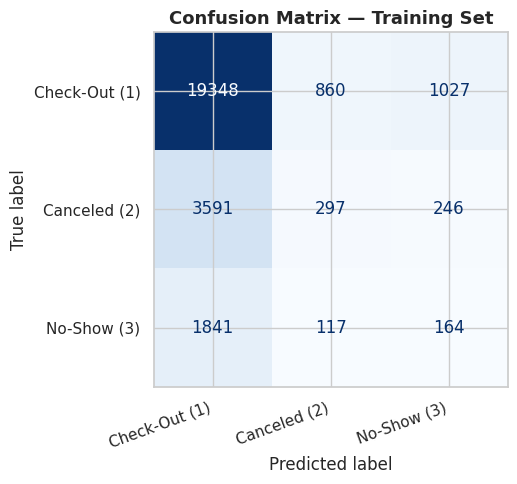

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_train = confusion_matrix(y_train_lgb, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Training Set', fontweight='bold', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('cm_train.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model Evaluation — Validation Dataset

In [32]:
y_pred_val   = final_model.predict(X_valid)
y_prob_val   = final_model.predict_proba(X_valid)

val_acc    = accuracy_score(y_valid_lgb, y_pred_val)
val_f1_wtd = f1_score(y_valid_lgb, y_pred_val, average='weighted')
val_f1_mac = f1_score(y_valid_lgb, y_pred_val, average='macro')
val_auc    = roc_auc_score(
    label_binarize(y_valid_lgb, classes=[0,1,2]),
    y_prob_val, average='macro', multi_class='ovr'
)

print('='*55)
print('         VALIDATION SET EVALUATION')
print('='*55)
print(f'Accuracy          : {val_acc:.4f}  ({val_acc*100:.2f}%)')
print(f'Weighted F1-Score : {val_f1_wtd:.4f}')
print(f'Macro F1-Score    : {val_f1_mac:.4f}')
print(f'ROC-AUC (macro)   : {val_auc:.4f}')
print()
print(classification_report(y_valid_lgb, y_pred_val, target_names=CLASS_NAMES))

         VALIDATION SET EVALUATION
Accuracy          : 0.5497  (54.97%)
Weighted F1-Score : 0.4519
Macro F1-Score    : 0.2981
ROC-AUC (macro)   : 0.4986

               precision    recall  f1-score   support

Check-Out (1)       0.59      0.90      0.71      1610
 Canceled (2)       0.29      0.04      0.08       741
  No-Show (3)       0.18      0.08      0.11       398

     accuracy                           0.55      2749
    macro avg       0.35      0.34      0.30      2749
 weighted avg       0.45      0.55      0.45      2749



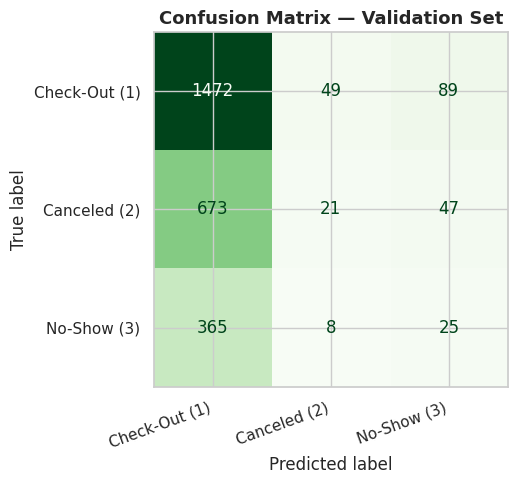

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_val = confusion_matrix(y_valid_lgb, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Validation Set', fontweight='bold', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('cm_valid.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Baseline vs. Tuned Model Comparison

                          Model  Val Accuracy  Val F1 (wtd)  Val F1 (macro)
              Baseline LightGBM        0.5584        0.4309          0.2598
Tuned LightGBM (SMOTE + Optuna)        0.5497        0.4519          0.2981


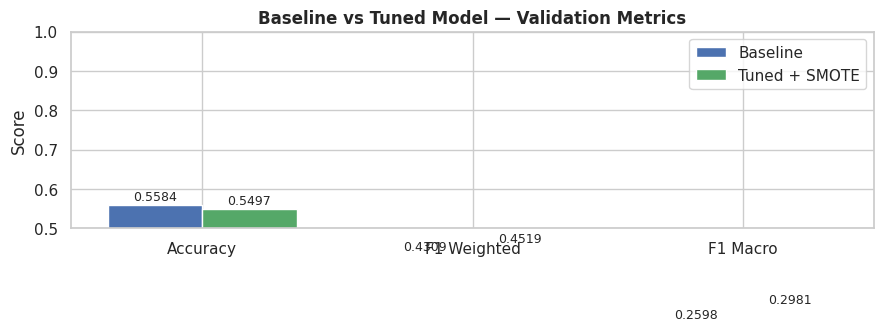

In [33]:
comparison = pd.DataFrame({
    'Model'         : ['Baseline LightGBM', 'Tuned LightGBM (SMOTE + Optuna)'],
    'Val Accuracy'  : [round(baseline_val_acc, 4), round(val_acc, 4)],
    'Val F1 (wtd)'  : [round(baseline_val_f1, 4), round(val_f1_wtd, 4)],
    'Val F1 (macro)': [round(f1_score(y_valid_lgb, y_pred_baseline_val, average='macro'), 4),
                       round(val_f1_mac, 4)]
})

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
w = 0.35
b_vals = [comparison['Val Accuracy'][0], comparison['Val F1 (wtd)'][0], comparison['Val F1 (macro)'][0]]
t_vals = [comparison['Val Accuracy'][1], comparison['Val F1 (wtd)'][1], comparison['Val F1 (macro)'][1]]
ax.bar(x - w/2, b_vals, w, label='Baseline', color='#4C72B0')
ax.bar(x + w/2, t_vals, w, label='Tuned + SMOTE', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Weighted', 'F1 Macro'])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned Model — Validation Metrics', fontweight='bold')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Importance

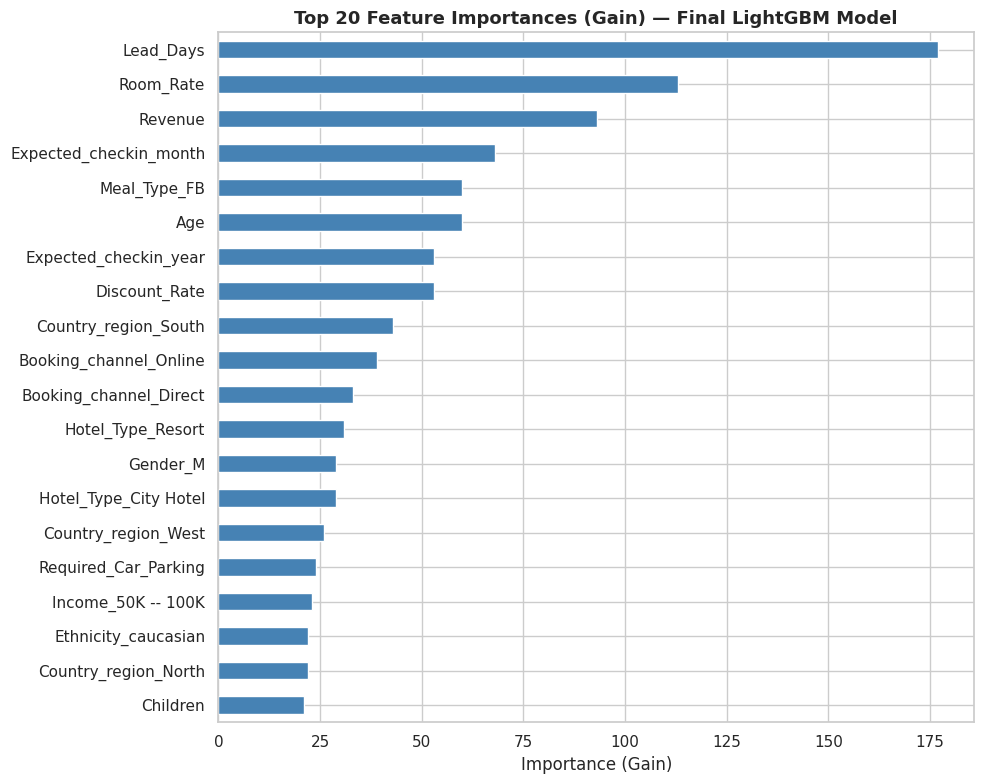


Top 10 Most Important Features:
Lead_Days                 177
Room_Rate                 113
Revenue                    93
Expected_checkin_month     68
Meal_Type_FB               60
Age                        60
Expected_checkin_year      53
Discount_Rate              53
Country_region_South       43
Booking_channel_Online     39


In [34]:
# LightGBM built-in feature importance (gain)
fi = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (Gain) — Final LightGBM Model', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Most Important Features:')
print(fi.head(10).to_string())

Shape of X_valid_sample: (500, 36)
Shape of shap_values: (500, 36, 3)
Shape of shap_values[:, :, 1]: (500, 36)


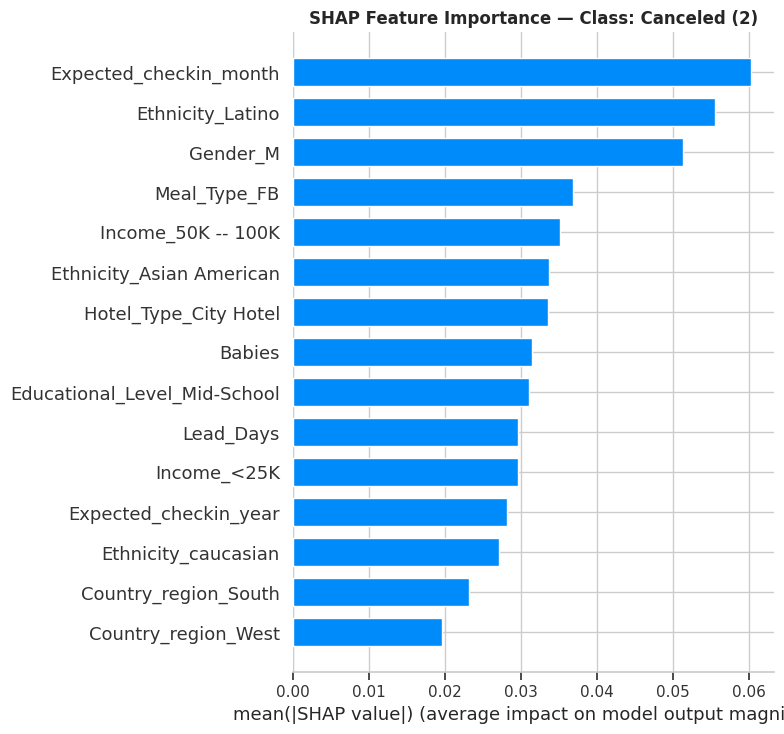

In [35]:
# SHAP summary plot for interpretability
explainer = shap.TreeExplainer(final_model)

X_valid_sample = X_valid.sample(500, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_valid_sample)

# DEBUG: Print shapes to diagnose AssertionError
print(f"Shape of X_valid_sample: {X_valid_sample.shape}")
# Check if shap_values is a list or array of arrays
if isinstance(shap_values, list):
    print(f"shap_values is a list of {len(shap_values)} arrays.")
    for i, val in enumerate(shap_values):
        print(f"  Shape of shap_values[{i}]: {val.shape}")
else:
    print(f"Shape of shap_values: {shap_values.shape}")
# Correct slicing for 3D shap_values array for a specific class (e.g., class 1)
# This line is for debugging and confirming the shape of the data that will be passed to summary_plot.
print(f"Shape of shap_values[:, :, 1]: {shap_values[:, :, 1].shape}")

# Plot for class 1 (Canceled)
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values[:, :, 1], # Corrected indexing for class 1 (Canceled)
    X_valid_sample,
    max_display=15,
    show=False,
    plot_type='bar'
)
plt.title('SHAP Feature Importance — Class: Canceled (2)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_canceled.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Test Set Predictions

In [36]:
y_pred_test      = final_model.predict(X_test)          # 0-indexed
y_pred_test_orig = y_pred_test + 1                      # back to 1,2,3
y_prob_test      = final_model.predict_proba(X_test)

status_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

submission = test_df[['Reservation_id']].copy()
submission['Predicted_Status']      = y_pred_test_orig
submission['Predicted_Label']       = submission['Predicted_Status'].map(status_map)
submission['Prob_CheckOut']         = y_prob_test[:, 0].round(4)
submission['Prob_Canceled']         = y_prob_test[:, 1].round(4)
submission['Prob_NoShow']           = y_prob_test[:, 2].round(4)

submission.to_csv('test_predictions.csv', index=False)

print(f'Test predictions saved → test_predictions.csv')
print(f'\nPrediction Distribution on Test Set:')
pred_dist = submission['Predicted_Label'].value_counts()
for lbl, cnt in pred_dist.items():
    print(f'  {lbl:<12}: {cnt:>5}  ({cnt/len(submission)*100:.1f}%)')

submission.head(10)

Test predictions saved → test_predictions.csv

Prediction Distribution on Test Set:
  Check-Out   :  4205  (97.4%)
  No-Show     :    63  (1.5%)
  Canceled    :    50  (1.2%)


,Reservation_id,Predicted_Status,Predicted_Label,Prob_CheckOut,Prob_Canceled,Prob_NoShow
0,62931593,1,Check-Out,0.6269,0.1754,0.1977
1,70586099,3,No-Show,0.3089,0.2781,0.4130
2,4230648,1,Check-Out,0.4451,0.2213,0.3336
3,25192322,1,Check-Out,0.3552,0.3342,0.3106
4,80931528,2,Canceled,0.3399,0.3511,0.3090
5,64700386,1,Check-Out,0.7035,0.1429,0.1535
6,16938050,3,No-Show,0.2203,0.3756,0.4041
7,90487908,1,Check-Out,0.4169,0.2151,0.3680
8,5595445,1,Check-Out,0.5861,0.2153,0.1986
9,17502557,1,Check-Out,0.4765,0.3152,0.2083


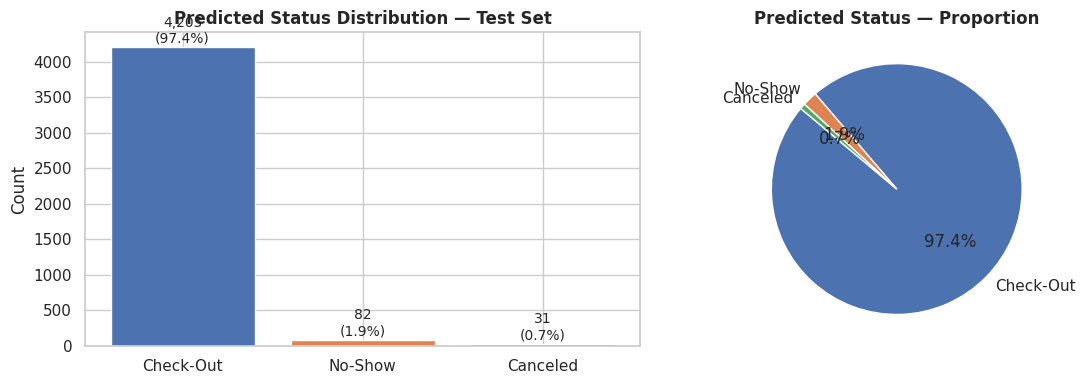

In [24]:
# Visualise test prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = submission['Predicted_Label'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{val:,}\n({val/len(submission)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Predicted Status Distribution — Test Set', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452','#55A868'], startangle=140)
axes[1].set_title('Predicted Status — Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('test_prediction_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.1. Hyperparameter Tuning with Optuna (Macro F1 Focused - Extended)

In [37]:
def objective_macro_f1(trial):
    params = {
        'objective'        : 'multiclass',
        'num_class'        : 3,
        'metric'           : 'multi_logloss',
        'n_estimators'     : 1000, # Increased n_estimators for longer training potential
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_jobs'           : -1,
        'random_state'     : RANDOM_STATE,
        'verbose'          : -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_bal, y_train_bal,
        eval_set=[(X_valid, y_valid_lgb)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(False)] # Increased early stopping rounds
    )
    preds = model.predict(X_valid)
    # Optimize for macro F1-score to address class imbalance bias
    return f1_score(y_valid_lgb, preds, average='macro')

study_macro_f1 = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
# Increased n_trials for a more thorough search
study_macro_f1.optimize(objective_macro_f1, n_trials=100, show_progress_bar=False)

print(f'Best Macro F1    : {study_macro_f1.best_value:.4f}')
print(f'Best Params      :\n{study_macro_f1.best_params}')

Best Macro F1    : 0.2981
Best Params      :
{'learning_rate': 0.18872906373795967, 'num_leaves': 77, 'max_depth': 7, 'min_child_samples': 52, 'subsample': 0.6015737644458422, 'colsample_bytree': 0.9357239586720052, 'reg_alpha': 1.1842939778980232e-08, 'reg_lambda': 3.8976036435348793}


## 7.1. Train Final Tuned Model (Macro F1 Optimized)

In [38]:
best_params_macro_f1 = study_macro_f1.best_params.copy()
best_params_macro_f1.update({
    'objective'   : 'multiclass',
    'num_class'   : 3,
    'metric'      : 'multi_logloss',
    'n_estimators': 1000, # Using high n_estimators with early stopping
    'n_jobs'      : -1,
    'random_state': RANDOM_STATE,
    'verbose'     : -1
})

final_model_macro_f1 = lgb.LGBMClassifier(**best_params_macro_f1)
final_model_macro_f1.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_valid, y_valid_lgb)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(100)] # Increased early stopping rounds
)

print(f'\n✅ Final model (Macro F1 optimized) trained | Best iteration: {final_model_macro_f1.best_iteration_}')

[100]	valid_0's multi_logloss: 1.28412

✅ Final model (Macro F1 optimized) trained | Best iteration: 6


## 8.1. Model Evaluation — Training Dataset (Macro F1 Optimized Model)

         TRAINING SET EVALUATION (Macro F1 Optimized Model)
Accuracy          : 0.7206  (72.06%)
Weighted F1-Score : 0.6732
Macro F1-Score    : 0.3476

               precision    recall  f1-score   support

Check-Out (1)       0.78      0.91      0.84     21235
 Canceled (2)       0.23      0.07      0.11      4134
  No-Show (3)       0.11      0.08      0.09      2122

     accuracy                           0.72     27491
    macro avg       0.38      0.35      0.35     27491
 weighted avg       0.65      0.72      0.67     27491



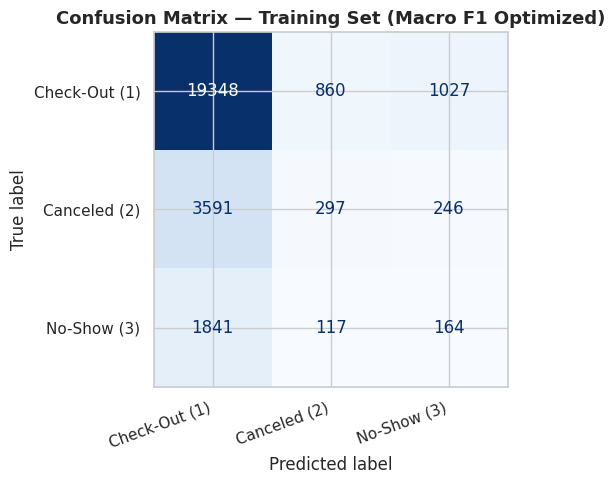

In [39]:
# Predict on training set (original, not SMOTE-balanced)
y_pred_train_macro_f1 = final_model_macro_f1.predict(X_train)
train_acc_macro_f1    = accuracy_score(y_train_lgb, y_pred_train_macro_f1)
train_f1_wtd_macro_f1 = f1_score(y_train_lgb, y_pred_train_macro_f1, average='weighted')
train_f1_mac_macro_f1 = f1_score(y_train_lgb, y_pred_train_macro_f1, average='macro')

print('='*55)
print('         TRAINING SET EVALUATION (Macro F1 Optimized Model)')
print('='*55)
print(f'Accuracy          : {train_acc_macro_f1:.4f}  ({train_acc_macro_f1*100:.2f}%)')
print(f'Weighted F1-Score : {train_f1_wtd_macro_f1:.4f}')
print(f'Macro F1-Score    : {train_f1_mac_macro_f1:.4f}')
print()
print(classification_report(y_train_lgb, y_pred_train_macro_f1, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(7, 5))
cm_train_macro_f1 = confusion_matrix(y_train_lgb, y_pred_train_macro_f1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train_macro_f1, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Training Set (Macro F1 Optimized)', fontweight='bold', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('cm_train_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.1. Model Evaluation — Validation Dataset (Macro F1 Optimized Model)

         VALIDATION SET EVALUATION (Macro F1 Optimized Model)
Accuracy          : 0.5497  (54.97%)
Weighted F1-Score : 0.4519
Macro F1-Score    : 0.2981
ROC-AUC (macro)   : 0.4986

               precision    recall  f1-score   support

Check-Out (1)       0.59      0.90      0.71      1610
 Canceled (2)       0.29      0.04      0.08       741
  No-Show (3)       0.18      0.08      0.11       398

     accuracy                           0.55      2749
    macro avg       0.35      0.34      0.30      2749
 weighted avg       0.45      0.55      0.45      2749



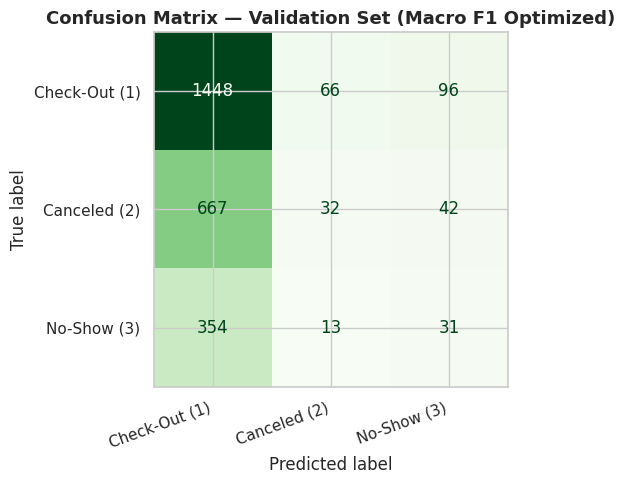

In [40]:
y_pred_val_macro_f1   = final_model_macro_f1.predict(X_valid)
y_prob_val_macro_f1   = final_model_macro_f1.predict_proba(X_valid)

val_acc_macro_f1    = accuracy_score(y_valid_lgb, y_pred_val_macro_f1)
val_f1_wtd_macro_f1 = f1_score(y_valid_lgb, y_pred_val_macro_f1, average='weighted')
val_f1_mac_macro_f1 = f1_score(y_valid_lgb, y_pred_val_macro_f1, average='macro')
val_auc_macro_f1    = roc_auc_score(
    label_binarize(y_valid_lgb, classes=[0,1,2]),
    y_prob_val_macro_f1, average='macro', multi_class='ovr'
)

print('='*55)
print('         VALIDATION SET EVALUATION (Macro F1 Optimized Model)')
print('='*55)
print(f'Accuracy          : {val_acc_macro_f1:.4f}  ({val_acc_macro_f1*100:.2f}%)')
print(f'Weighted F1-Score : {val_f1_wtd_macro_f1:.4f}')
print(f'Macro F1-Score    : {val_f1_mac_macro_f1:.4f}')
print(f'ROC-AUC (macro)   : {val_auc_macro_f1:.4f}')
print()
print(classification_report(y_valid_lgb, y_pred_val_macro_f1, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(7, 5))
cm_val_macro_f1 = confusion_matrix(y_valid_lgb, y_pred_val_macro_f1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val_macro_f1, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Validation Set (Macro F1 Optimized)', fontweight='bold', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('cm_valid_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 10.1. Model Comparison: Baseline vs. Tuned (Original) vs. Tuned (Macro F1 Optimized)

                          Model  Val Accuracy  Val F1 (wtd)  Val F1 (macro)
              Baseline LightGBM        0.5584        0.4309          0.2598
Tuned LightGBM (SMOTE + Optuna)        0.5497        0.4519          0.2981
     Tuned (Macro F1 Optimized)        0.5497        0.4519          0.2981


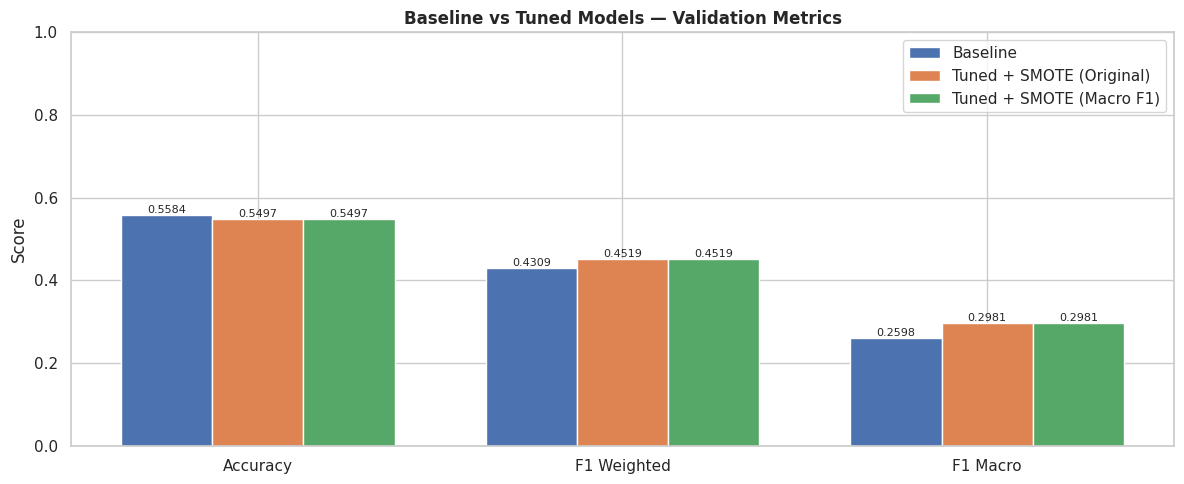

In [42]:
comparison_extended = pd.DataFrame({
    'Model'         : ['Baseline LightGBM', 'Tuned LightGBM (SMOTE + Optuna)', 'Tuned (Macro F1 Optimized)'],
    'Val Accuracy'  : [round(baseline_val_acc, 4), round(val_acc, 4), round(val_acc_macro_f1, 4)],
    'Val F1 (wtd)'  : [round(baseline_val_f1, 4), round(val_f1_wtd, 4), round(val_f1_wtd_macro_f1, 4)],
    'Val F1 (macro)': [round(f1_score(y_valid_lgb, y_pred_baseline_val, average='macro'), 4),
                       round(val_f1_mac, 4),
                       round(val_f1_mac_macro_f1, 4)]
})

print(comparison_extended.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(3)
w = 0.25

b_vals = [comparison_extended['Val Accuracy'][0], comparison_extended['Val F1 (wtd)'][0], comparison_extended['Val F1 (macro)'][0]]
t_vals = [comparison_extended['Val Accuracy'][1], comparison_extended['Val F1 (wtd)'][1], comparison_extended['Val F1 (macro)'][1]]
m_vals = [comparison_extended['Val Accuracy'][2], comparison_extended['Val F1 (wtd)'][2], comparison_extended['Val F1 (macro)'][2]]

ax.bar(x - w, b_vals, w, label='Baseline', color='#4C72B0')
ax.bar(x, t_vals, w, label='Tuned + SMOTE (Original)', color='#DD8452')
ax.bar(x + w, m_vals, w, label='Tuned + SMOTE (Macro F1)', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Weighted', 'F1 Macro'])
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned Models — Validation Metrics', fontweight='bold')
ax.legend()
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.4f', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison_extended.png', dpi=150, bbox_inches='tight')
plt.show()

## 11.1. Feature Importance (Macro F1 Optimized Model)

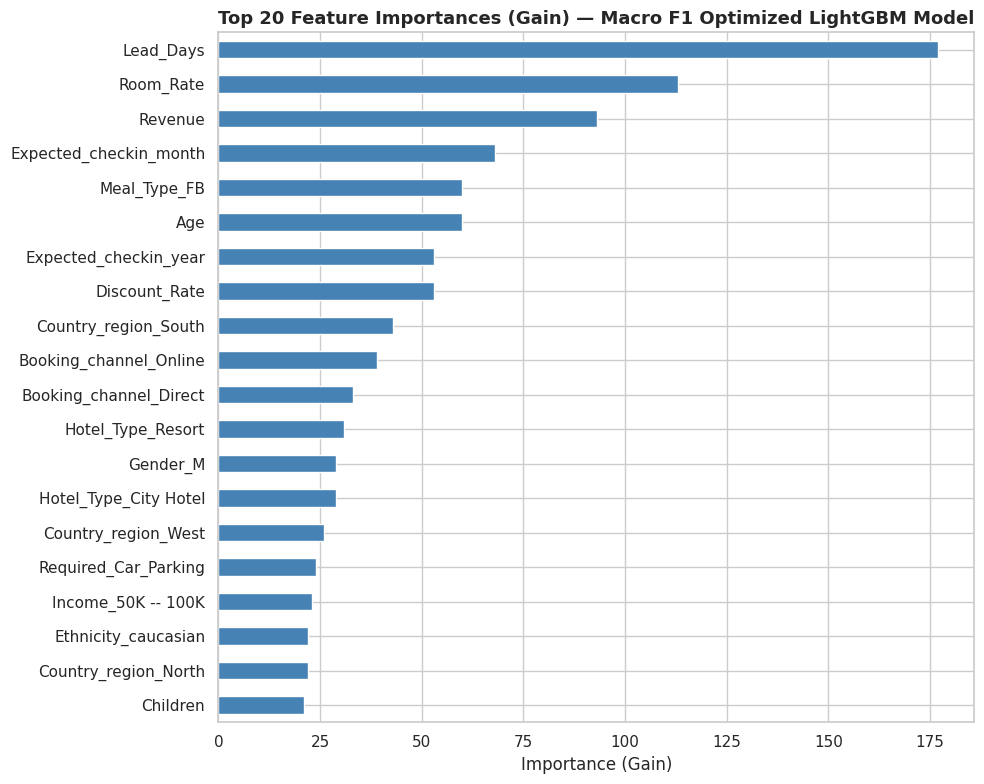


Top 10 Most Important Features (Macro F1 Optimized Model):
Lead_Days                 177
Room_Rate                 113
Revenue                    93
Expected_checkin_month     68
Meal_Type_FB               60
Age                        60
Expected_checkin_year      53
Discount_Rate              53
Country_region_South       43
Booking_channel_Online     39


In [43]:
# LightGBM built-in feature importance (gain) for Macro F1 Optimized Model
fi_macro_f1 = pd.Series(final_model_macro_f1.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi_macro_f1.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (Gain) — Macro F1 Optimized LightGBM Model', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Most Important Features (Macro F1 Optimized Model):')
print(fi_macro_f1.head(10).to_string())

## 11.2. SHAP Summary Plot (Macro F1 Optimized Model)

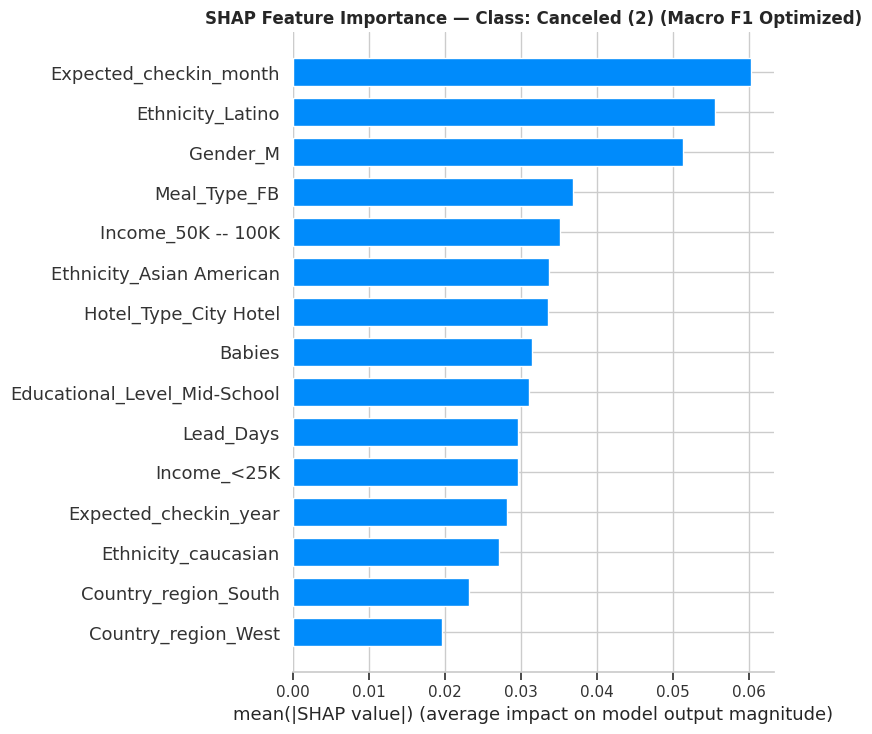

In [44]:
# SHAP summary plot for interpretability of Macro F1 Optimized Model
explainer_macro_f1 = shap.TreeExplainer(final_model_macro_f1)

# Ensure X_valid_sample is the same as used previously for consistency
shap_values_macro_f1 = explainer_macro_f1.shap_values(X_valid_sample)

# Plot for class 1 (Canceled)
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values_macro_f1[:, :, 1], # Corrected indexing for class 1 (Canceled)
    X_valid_sample,
    max_display=15,
    show=False,
    plot_type='bar'
)
plt.title('SHAP Feature Importance — Class: Canceled (2) (Macro F1 Optimized)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_canceled_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.1. Test Set Predictions (Macro F1 Optimized Model)

Test predictions (Macro F1 Optimized) saved → test_predictions_macro_f1.csv

Prediction Distribution on Test Set (Macro F1 Optimized Model):
  Check-Out   :  4205  (97.4%)
  No-Show     :    63  (1.5%)
  Canceled    :    50  (1.2%)


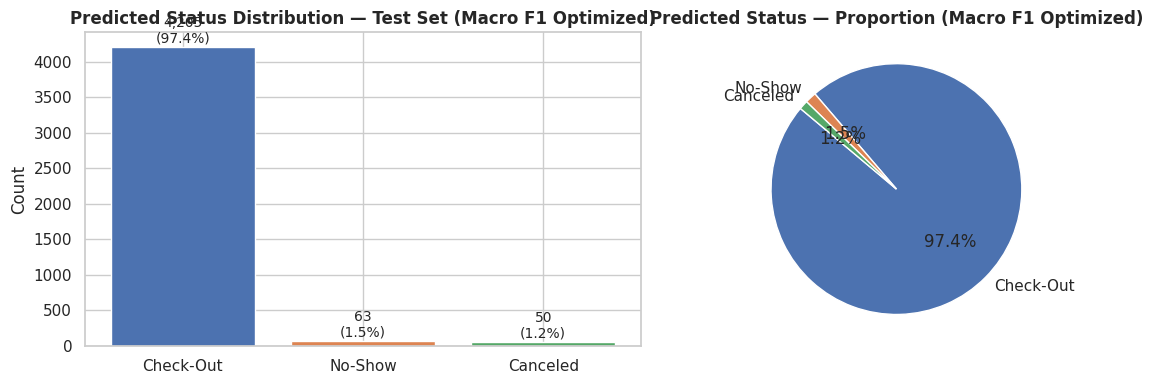

,Reservation_id,Predicted_Status,Predicted_Label,Prob_CheckOut,Prob_Canceled,Prob_NoShow
0,62931593,1,Check-Out,0.6269,0.1754,0.1977
1,70586099,3,No-Show,0.3089,0.2781,0.4130
2,4230648,1,Check-Out,0.4451,0.2213,0.3336
3,25192322,1,Check-Out,0.3552,0.3342,0.3106
4,80931528,2,Canceled,0.3399,0.3511,0.3090
5,64700386,1,Check-Out,0.7035,0.1429,0.1535
6,16938050,3,No-Show,0.2203,0.3756,0.4041
7,90487908,1,Check-Out,0.4169,0.2151,0.3680
8,5595445,1,Check-Out,0.5861,0.2153,0.1986
9,17502557,1,Check-Out,0.4765,0.3152,0.2083


In [45]:
y_pred_test_macro_f1      = final_model_macro_f1.predict(X_test)          # 0-indexed
y_pred_test_orig_macro_f1 = y_pred_test_macro_f1 + 1                      # back to 1,2,3
y_prob_test_macro_f1      = final_model_macro_f1.predict_proba(X_test)

submission_macro_f1 = test_df[['Reservation_id']].copy()
submission_macro_f1['Predicted_Status']      = y_pred_test_orig_macro_f1
submission_macro_f1['Predicted_Label']       = submission_macro_f1['Predicted_Status'].map(status_map)
submission_macro_f1['Prob_CheckOut']         = y_prob_test_macro_f1[:, 0].round(4)
submission_macro_f1['Prob_Canceled']         = y_prob_test_macro_f1[:, 1].round(4)
submission_macro_f1['Prob_NoShow']           = y_prob_test_macro_f1[:, 2].round(4)

submission_macro_f1.to_csv('test_predictions_macro_f1.csv', index=False)

print(f'Test predictions (Macro F1 Optimized) saved → test_predictions_macro_f1.csv')
print(f'\nPrediction Distribution on Test Set (Macro F1 Optimized Model):')
pred_dist_macro_f1 = submission_macro_f1['Predicted_Label'].value_counts()
for lbl, cnt in pred_dist_macro_f1.items():
    print(f'  {lbl:<12}: {cnt:>5}  ({cnt/len(submission_macro_f1)*100:.1f}%)')


# Visualise test prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts_macro_f1 = submission_macro_f1['Predicted_Label'].value_counts()
bars = axes[0].bar(counts_macro_f1.index, counts_macro_f1.values, color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
for bar, val in zip(bars, counts_macro_f1.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{val:,}\n({val/len(submission_macro_f1)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Predicted Status Distribution — Test Set (Macro F1 Optimized)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts_macro_f1.values, labels=counts_macro_f1.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452','#55A868'], startangle=140)
axes[1].set_title('Predicted Status — Proportion (Macro F1 Optimized)', fontweight='bold')

plt.tight_layout()
plt.savefig('test_prediction_dist_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

submission_macro_f1.head(10)

## 13.1. Final Summary (Macro F1 Optimized Model)

In [ ]:
print('='*60)
print('         FINAL MODEL PERFORMANCE SUMMARY (Macro F1 Optimized)')
print('='*60)
print()
print('  TRAINING SET (original, post-SMOTE model)')
print(f'    Accuracy          : {train_acc_macro_f1:.4f} ({train_acc_macro_f1*100:.2f}%)')
print(f'    Weighted F1-Score : {train_f1_wtd_macro_f1:.4f}')
print(f'    Macro F1-Score    : {train_f1_mac_macro_f1:.4f}')
print()
print('  VALIDATION SET')
print(f'    Accuracy          : {val_acc_macro_f1:.4f} ({val_acc_macro_f1*100:.2f}%)')
print(f'    Weighted F1-Score : {val_f1_wtd_macro_f1:.4f}')
print(f'    Macro F1-Score    : {val_f1_mac_macro_f1:.4f}')
print(f'    ROC-AUC (macro)   : {val_auc_macro_f1:.4f}')
print()
print('  TEST SET')
print(f'    Predictions saved to: test_predictions_macro_f1.csv')
print(f'    Total records       : {len(submission_macro_f1):,}')
print()
print('='*60)
print('  Key hyperparameters (Optuna best - Macro F1 Optimized):')
for k, v in study_macro_f1.best_params.items():
    print(f'    {k:<22}: {v}')
print('='*60)